# 01 — Data Audit

**What this notebook does:** Reads the outputs of `scripts/test_open_datasets.py` and presents the dataset access audit as a navigable summary for project stakeholders. Run `scripts/test_open_datasets.py` first to generate today's CSV.

**Date:** 2026-05-05  
**Author:** Jack Beard (Green in Blue)  
**Audience:** Severn Trent Water (Matt Palmer) and project team

---

This notebook is a **thin narrative layer** over the audit pipeline. All probing logic lives in `scripts/test_open_datasets.py` and `src/data_access.py`. Re-run the script to refresh; re-run this notebook to update the display.

Key reference docs:
- [`docs/methodology/01_data_audit_findings.md`](../docs/methodology/01_data_audit_findings.md) — detailed findings and methodology notes
- [`docs/methodology/04_coverage_gaps_and_welsh_data.md`](../docs/methodology/04_coverage_gaps_and_welsh_data.md) — Welsh data gap analysis

## 0. AOI — STW Plc Full Operational Footprint

The project AOI is the **union of all four STW Plc service-area boundaries** (ST Clean Water, ST Wastewater, HD Clean Water, HD Wastewater). The merged boundary is at `data/processed/stw_full_aoi.gpkg`; a diagnostic components layer is at `data/processed/aoi_components.gpkg`.

Run `scripts/preprocess_aoi.py` to generate these files if they do not yet exist.  
See [`docs/methodology/04_coverage_gaps_and_welsh_data.md`](../docs/methodology/04_coverage_gaps_and_welsh_data.md) for the Hafren Dyfrdwy (HD) subsidiary explanation and Wales coverage gap analysis.

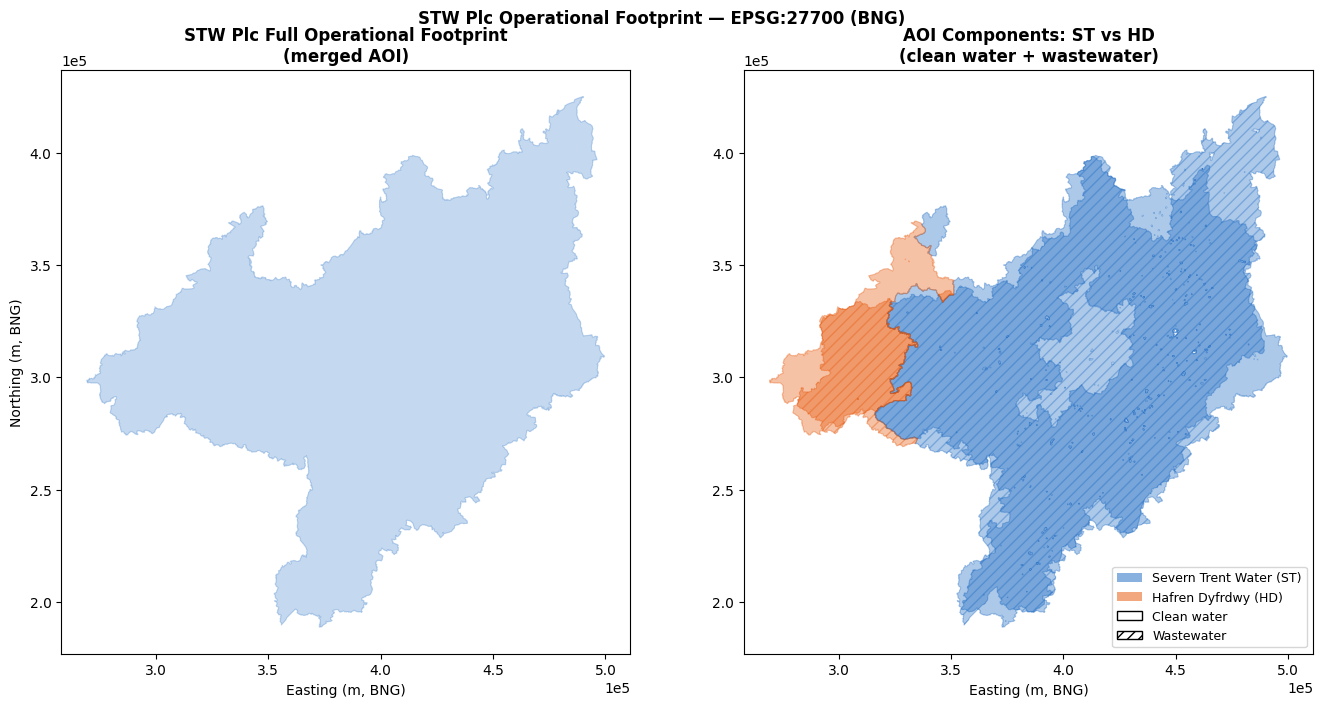

Total AOI area: 24,368 km²

Component breakdown:
  HD clean_water        2,855 km²
  HD waste              1,903 km²
  ST clean_water       17,645 km²
  ST waste             19,510 km²


In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

AOI_PATH = Path("..") / "data" / "processed" / "stw_full_aoi.gpkg"
COMPONENTS_PATH = Path("..") / "data" / "processed" / "aoi_components.gpkg"

if not AOI_PATH.exists():
    print(
        f"AOI file not found: {AOI_PATH}\n"
        "Run:  python scripts/preprocess_aoi.py --boundaries-dir PATH/TO/DATA/GIS/Boundaries"
    )
else:
    aoi = gpd.read_file(AOI_PATH, layer="stw_full_aoi")
    components = gpd.read_file(COMPONENTS_PATH, layer="aoi_components")

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Left panel: merged AOI
    aoi.plot(ax=axes[0], color="#1565c0", alpha=0.25, edgecolor="#1565c0", linewidth=0.8)
    axes[0].set_title("STW Plc Full Operational Footprint\n(merged AOI)", fontweight="bold")
    axes[0].set_xlabel("Easting (m, BNG)")
    axes[0].set_ylabel("Northing (m, BNG)")
    axes[0].ticklabel_format(style="sci", scilimits=(0, 0), axis="both")

    # Right panel: components coloured by subsidiary, hatched by service type
    COLORS = {"ST": "#1565c0", "HD": "#e65100"}
    HATCHES = {"clean_water": "", "waste": "///"}
    for _, row in components.iterrows():
        sub = row["subsidiary"]
        svc = row["service_type"]
        gpd.GeoDataFrame({"geometry": [row.geometry]}, crs=components.crs).plot(
            ax=axes[1],
            color=COLORS.get(sub, "#78909c"),
            alpha=0.35,
            edgecolor=COLORS.get(sub, "#78909c"),
            linewidth=0.8,
            hatch=HATCHES.get(svc, ""),
        )

    legend_patches = [
        mpatches.Patch(facecolor="#1565c0", alpha=0.5, label="Severn Trent Water (ST)"),
        mpatches.Patch(facecolor="#e65100", alpha=0.5, label="Hafren Dyfrdwy (HD)"),
        mpatches.Patch(facecolor="white", edgecolor="black", label="Clean water"),
        mpatches.Patch(facecolor="white", edgecolor="black", hatch="///", label="Wastewater"),
    ]
    axes[1].legend(handles=legend_patches, loc="lower right", fontsize=9)
    axes[1].set_title("AOI Components: ST vs HD\n(clean water + wastewater)", fontweight="bold")
    axes[1].set_xlabel("Easting (m, BNG)")
    axes[1].ticklabel_format(style="sci", scilimits=(0, 0), axis="both")

    plt.suptitle("STW Plc Operational Footprint — EPSG:27700 (BNG)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    total_km2 = aoi.geometry.area.sum() / 1e6
    print(f"Total AOI area: {total_km2:,.0f} km²\n")
    print("Component breakdown:")
    for (sub, svc), grp in components.groupby(["subsidiary", "service_type"]):
        area = grp.geometry.area.sum() / 1e6
        print(f"  {sub} {svc:<15} {area:>8,.0f} km²")

In [2]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Allow imports from repo root
sys.path.insert(0, str(Path("..").resolve()))

# Locate the most recent audit CSV
AUDIT_DIR = Path("..") / "outputs" / "data_audit"
csv_files = sorted(AUDIT_DIR.glob("dataset_access_*.csv"), reverse=True)
if not csv_files:
    raise FileNotFoundError(
        "No audit CSV found in outputs/data_audit/. "
        "Run: python scripts/test_open_datasets.py"
    )

AUDIT_CSV = csv_files[0]
print(f"Loading: {AUDIT_CSV.name}")
df = pd.read_csv(AUDIT_CSV)
print(f"  {len(df)} rows loaded")

Loading: dataset_access_20260602.csv
  30 rows loaded


## 1. Audit Summary

The table below shows what proportion of the dataset registry is programmatically accessible
(WFS or ArcGIS FeatureServer) vs requiring manual download. The audit script probes each endpoint
and writes the result to the CSV; this notebook reads that output.

In [3]:
core = df[df["experimental"] == False].copy()
exp  = df[df["experimental"] == True].copy()

# Friendly probe-result labels
LABEL = {
    "ok":       "Programmatically accessible",
    "page_ok":  "Landing page reachable (manual download)",
    "pending":  "URL not yet confirmed",
    "page_fail":"Landing page unreachable",
    "fail":     "Endpoint error",
    "no_url":   "No URL (pending data share)",
}
core["status"] = core["probe_result"].map(LABEL).fillna(core["probe_result"])

def style_probe(val):
    """Cell styler for probe_result values — returns a CSS string."""
    css = {
        "ok":        "background-color: #e8f5e9; color: #1b5e20",
        "page_ok":   "background-color: #fff8e1; color: #e65100",
        "pending":   "background-color: #eceff1; color: #546e7a",
        "no_url":    "background-color: #eceff1; color: #546e7a",
        "fail":      "background-color: #ffebee; color: #b71c1c",
        "page_fail": "background-color: #ffebee; color: #b71c1c",
    }
    return css.get(str(val), "")

summary = (
    core["status"]
    .value_counts()
    .rename_axis("Status")
    .reset_index(name="Count")
)
summary["Pct"] = (summary["Count"] / len(core) * 100).round(1).astype(str) + "%"
print(f"Core datasets: {len(core)} total")
display(summary)

Core datasets: 19 total


,Status,Count,Pct
0,Programmatically accessible,17,89.5%
1,Landing page reachable (manual download),2,10.5%


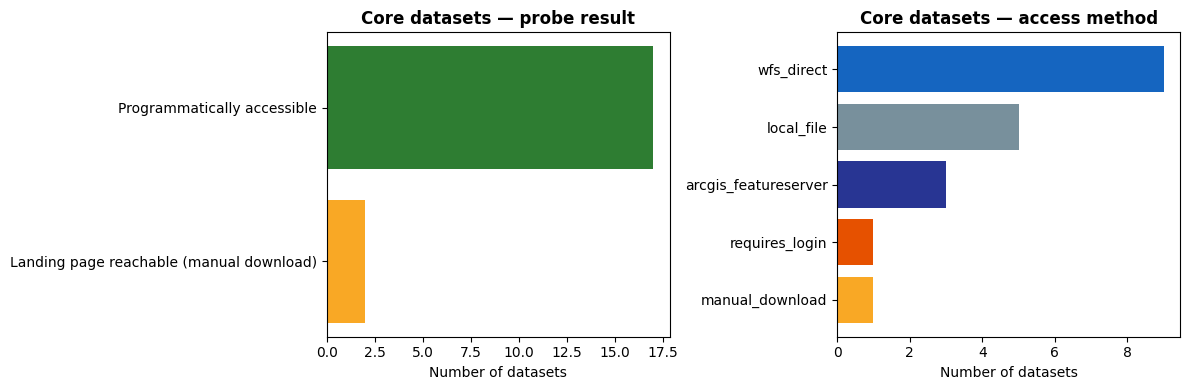


Programmatically accessible (API): 17/19
Manual download needed:            2/19


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: probe result breakdown
COLOR_MAP = {
    "Programmatically accessible": "#2e7d32",
    "Landing page reachable (manual download)": "#f9a825",
    "URL not yet confirmed": "#90a4ae",
    "No URL (pending data share)": "#b0bec5",
    "Endpoint error": "#c62828",
}
colors = [COLOR_MAP.get(s, "#78909c") for s in summary["Status"]]
axes[0].barh(summary["Status"], summary["Count"], color=colors)
axes[0].set_xlabel("Number of datasets")
axes[0].set_title("Core datasets — probe result", fontweight="bold")
axes[0].invert_yaxis()

# Right: access method breakdown
method_counts = core["access_method"].value_counts()
METHOD_COLORS = {
    "wfs_direct": "#1565c0",
    "arcgis_featureserver": "#283593",
    "arcgis_static_download": "#4527a0",
    "manual_download": "#f9a825",
    "requires_login": "#e65100",
    "pending_url": "#90a4ae",
}
mc_colors = [METHOD_COLORS.get(m, "#78909c") for m in method_counts.index]
axes[1].barh(method_counts.index, method_counts.values, color=mc_colors)
axes[1].set_xlabel("Number of datasets")
axes[1].set_title("Core datasets — access method", fontweight="bold")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nProgrammatically accessible (API): {(core['probe_result']=='ok').sum()}/{len(core)}")
print(f"Manual download needed:            {(core['probe_result']=='page_ok').sum()}/{len(core)}")

## 2. Dataset Detail — Core Registry

Full list of the 18 core datasets, grouped by category. Access method and probe result shown for each.

**Probe result key:**
- `ok` — endpoint confirmed accessible (WFS GetCapabilities or ArcGIS JSON response returned)
- `page_ok` — landing page returns HTTP 200 (manual download required, data not verified)
- `page_fail` — landing page unreachable (potential link rot)

## 3. Coverage Gap Matrix

The **coverage** field records the spatial jurisdiction of each dataset: `england` (England-only) or `gb` (Great Britain — covers Wales).

**Why this matters:** The STW Plc operational footprint includes the **Hafren Dyfrdwy (HD)** Welsh subsidiary, which serves mid-Wales and parts of north-east Wales (Powys, Wrexham, Denbighshire). England-only datasets will produce blank outputs for the Welsh portion of the AOI. See [`docs/methodology/04_coverage_gaps_and_welsh_data.md`](../docs/methodology/04_coverage_gaps_and_welsh_data.md) for full analysis and the Phase 1.5 backlog of Welsh equivalent datasets.

> **AOI note:** The canonical AOI is the merged STW Plc full operational footprint (`data/processed/stw_full_aoi.gpkg`). The earlier finding that Welshpool, Newtown, and Llanidloes fell "outside the AOI" was based on `ST_Clean_Water_Service_Area.shp` alone — those towns are inside HD's service area and are therefore within the merged AOI. The Wales-portion area percentage is reported by `scripts/preprocess_aoi.py`.

## 3. Coverage Gap Matrix

The **coverage** field records the spatial jurisdiction of each dataset: `england` (England-only) or `gb` (Great Britain — covers Wales).

**Why this matters:** The STW operational area may extend into Wales (upper Severn catchment, Powys). England-only datasets will produce blank outputs for any Welsh portion. See `docs/methodology/04_coverage_gaps_and_welsh_data.md` for full analysis and Phase 1.5 backlog of Welsh equivalents.

> **AOI finding:** The provided `ST_Clean_Water_Service_Area.shp` boundary (BNG xmin=316133) appears to be England-only — test points at Welshpool, Newtown, and Llanidloes all fall outside. If the STW source catchment extends into Wales, a separate Welsh AOI boundary is needed.

In [5]:
from src.datasets import NBS_TYPES, EXPERIMENTAL_NBS_TYPES

core_nbs_types = [t for t in NBS_TYPES if t not in EXPERIMENTAL_NBS_TYPES]

rows = []
for nbs_type in core_nbs_types:
    # Rows that apply to this NbS type (nbs_types is a comma-separated string)
    mask = core["nbs_types"].apply(
        lambda s: nbs_type in s.split(", ") or "all" in s.split(", ")
    )
    type_rows = core[mask]
    for cat in ["opportunity", "constraint", "supplementary", "multi"]:
        cat_rows = type_rows[type_rows["category"] == cat]
        if cat_rows.empty:
            continue
        eng = (cat_rows["coverage"] == "england").sum()
        gb  = (cat_rows["coverage"] == "gb").sum()
        rows.append({
            "NbS type": nbs_type,
            "Category": cat,
            "england-only": eng,
            "gb (covers Wales)": gb,
            "Total layers": len(cat_rows),
        })

gap_df = pd.DataFrame(rows)

def style_gap(val):
    if isinstance(val, (int, float)) and val > 0:
        col = val  # column name not available in applymap, rely on caller
    return ""

def highlight_england(s):
    return [
        "background-color: #fff3e0" if v > 0 else ""
        for v in s
    ]

display(
    gap_df.style
    .apply(highlight_england, subset=["england-only"])
    .set_properties(**{"font-size": "12px"})
    .hide(axis="index")
    .set_caption("Orange = England-only layers that will produce blank output for Welsh STW area")
)

eng_total = core[core["coverage"] == "england"].shape[0]
gb_total  = core[core["coverage"] == "gb"].shape[0]
print(f"\nCore datasets: {eng_total} England-only | {gb_total} GB (covers Wales)")

NbS type,Category,england-only,gb (covers Wales),Total layers
pond_pool_scrape,opportunity,1,0,1
pond_pool_scrape,constraint,1,2,3
pond_pool_scrape,supplementary,4,1,5
pond_pool_scrape,multi,0,1,1
leaky_barriers,opportunity,1,1,2
leaky_barriers,constraint,2,2,4
leaky_barriers,supplementary,4,1,5
leaky_barriers,multi,0,2,2
bunds,opportunity,1,1,2
bunds,constraint,1,2,3



Core datasets: 13 England-only | 6 GB (covers Wales)


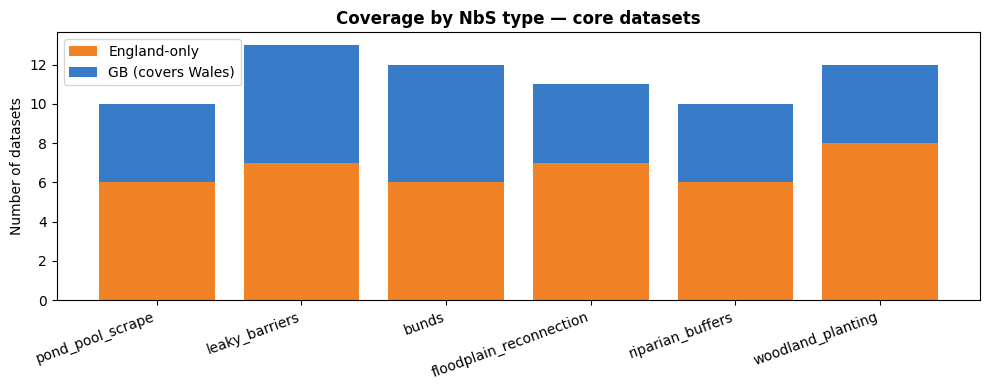

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

nbs_labels = gap_df["NbS type"].unique()
x = range(len(nbs_labels))
nbs_idx = {n: i for i, n in enumerate(nbs_labels)}

eng_counts = gap_df.groupby("NbS type")["england-only"].sum().reindex(nbs_labels, fill_value=0)
gb_counts  = gap_df.groupby("NbS type")["gb (covers Wales)"].sum().reindex(nbs_labels, fill_value=0)

ax.bar(x, eng_counts, label="England-only", color="#ef6c00", alpha=0.85)
ax.bar(x, gb_counts, bottom=eng_counts, label="GB (covers Wales)", color="#1565c0", alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(nbs_labels, rotation=20, ha="right")
ax.set_ylabel("Number of datasets")
ax.set_title("Coverage by NbS type — core datasets", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Experimental: Peat Restoration

The `peat_restoration` NbS type is an experimental 7th type added to the pipeline scaffold. It is not part of the original R methodology and is gated by `INCLUDE_EXPERIMENTAL` in `src/datasets.py`.

**Status:** Awaiting stakeholder go/no-go from Matt Palmer (Severn Trent). Severn Trent is a named partner in **Moor Resilience 2030** (£25m peatland restoration programme), which makes this a plausible addition to the deliverable scope.

**Data availability:** All peat restoration datasets use the **Natural England England Peat Map** (published May 2025), accessed via the NE ArcGIS Hub. **All are England-only** — a Welsh equivalent (WNPAP inventory) exists but has not been evaluated.

See `docs/methodology/03_peat_restoration_experimental.md` for the three-step methodology.

In [7]:
if exp.empty:
    print("No experimental entries loaded (INCLUDE_EXPERIMENTAL=False or no experimental datasets)")
else:
    exp["status"] = exp["probe_result"].map(LABEL).fillna(exp["probe_result"])
    print(f"Experimental peat restoration datasets: {len(exp)} total")
    print(f"  Accessible:  {(exp['probe_result']=='ok').sum()}")
    print(f"  Manual:      {(exp['probe_result']=='page_ok').sum()}")
    print(f"  Pending URL: {(exp['probe_result'].isin(['pending','no_url'])).sum()}")
    print(f"  Failed:      {(exp['probe_result']=='fail').sum()}")
    print()

    EXP_COLS = ["name", "category", "coverage", "access_method", "probe_result", "layer_name"]
    display(
        exp[EXP_COLS].style
        .map(style_probe, subset=["probe_result"])
        .set_properties(**{"font-size": "12px"})
        .hide(axis="index")
        .set_caption("Experimental peat restoration datasets — England Peat Map suite (NE ArcGIS Hub)")
    )

Experimental peat restoration datasets: 11 total
  Accessible:  11
  Manual:      0
  Pending URL: 0
  Failed:      0



name,category,coverage,access_method,probe_result,layer_name
England Peat Map — Peaty Soil Extent,opportunity,england,arcgis_featureserver,ok,peaty_soil_extent_v1
England Peat Map — Peaty Soil Depth,opportunity,england,arcgis_static_download,ok,geotiff ~475 MB
England Peat Map — Peaty Soil Depth Confidence,opportunity,england,arcgis_static_download,ok,geotiff
England Peat Map — Bare Peaty Soil,opportunity,england,arcgis_featureserver,ok,"8 BGZ layers: 13, 11, 6, 5, 4"
England Peat Map — Upland Grips,opportunity,england,arcgis_featureserver,ok,Upland Peat Erosion and Drainage Grips
England Peat Map — Upland Gullies,opportunity,england,arcgis_featureserver,ok,Upland Peat Erosion and Drainage Gullies
England Peat Map — Upland Haggs,opportunity,england,arcgis_featureserver,ok,Upland Peat Erosion and Drainage Haggs
England Peat Map — Vegetation and Land Cover on Peaty Soils,opportunity,england,arcgis_featureserver,ok,"14 BGZ layers: 14, 13, 12, 11, 10"
"England Peat Map — Status, GHG and Carbon Storage",supplementary,england,arcgis_featureserver,ok,England Peat Status GHG and C storage © BGS & NSRI
England Peat Map — Grip Dams,supplementary,england,arcgis_featureserver,ok,Upland Peat Erosion and Drainage Grip Dams


## 5. Manual Download Queue

These datasets require human action before the pipeline can run. Priority order:

1. **CEH Land Cover Map 2023 Polygon** — Register at EIDC (free account). One download covers all derived uses (constraint mask + baseline land-use supplementary).
2. **OS Zoomstack GeoPackage** — Free download from OS Data Hub (OGL). Contains Roads and Railways layers.
3. **BGS Soil Parent Material Model** — Free download from BGS website.
4. **OS Waterlines (Local)** — Await Matt Palmer's answer on OS PSGA share. Fallback: OS Open Rivers GeoPackage.
5. **EA NbS Infiltration Class** — Formal EA data request required (STW does not hold this dataset).

The cell below lists any core datasets where the probe result indicates action is needed.

In [8]:
needs_action = core[core["probe_result"] != "ok"][
    ["name", "category", "access_method", "probe_result", "notes"]
].reset_index(drop=True)

if needs_action.empty:
    print("All core datasets are programmatically accessible. No manual downloads needed.")
else:
    print(f"{len(needs_action)} datasets require manual action:\n")
    display(
        needs_action.style
        .map(style_probe, subset=["probe_result"])
        .set_properties(**{"font-size": "12px"})
        .hide(axis="index")
    )

2 datasets require manual action:



name,category,access_method,probe_result,notes
CEH Land Cover Map 2023 Polygon,multi,requires_login,page_ok,"[derived_uses: constraint, supplementary] Free EIDC account required. TODO: confirm exact EIDC catalogue URL for 2023 polygon edition. LCM class codes in derived_uses are from the 2021 edition; verify against the 2023 legend before use. Constraint filter excludes coniferous woodland (class 2) by design — see docs/methodology/02_architecture_vector_only.md."
EA NbS Infiltration Class,supplementary,manual_download,page_ok,"ArcGIS web app only; underlying REST service not publicly documented. Severn Trent do NOT hold this dataset — must be requested directly from the EA. BGS Groundwater Vulnerability Map is the licensed substitute, pending confirmation of commercial-use terms. Phase 1.5 TODO: raise formal EA data request."


## 6. Next Steps

| Priority | Action | Owner |
|---|---|---|
| 1 | Define Severn Trent AOI boundary (WFD catchment or service area) | Jack / STW |
| 2 | EIDC registration → download CEH LCM 2023 Polygon | Jack |
| 3 | OS Data Hub → download OS Open Zoomstack GeoPackage (Roads + Railways) | Jack |
| 4 | BGS website → download Soil Parent Material Model | Jack |
| 5 | Await Matt Palmer: OS PSGA share for OS Waterlines (Local) | Matt Palmer |
| 6 | Formal EA data request: EA NbS Infiltration Class raster | Jack / STW |
| 7 | Confirm BGS Groundwater Vulnerability licence scope | Matt Palmer |
| 8 | Peat restoration go/no-go: include as 7th NbS type? | Matt Palmer |
| 9 | Confirm whether Welsh source catchment is in scope | Matt Palmer |

**Phase 1.5 (after constraints pipeline is running):**
- BGS WFS client (`ogc.bgs.ac.uk`)
- OS Data Hub Features API (programmatic Roads/Railways)
- Welsh equivalent datasets (NRW, DataMapWales) if Welsh scope confirmed

## 4. Summary & Access Method Matrix

Based on the tests above, we can now classify each dataset by access method.

## 5. Next Steps

After running this notebook:

1. **Update the summary table** above with actual results from the API tests
2. **For datasets without WFS**: Check if direct download links exist on the dataset pages
3. **For CEH Land Cover**: Register at EIDC if needed, or explore alternative open datasets
4. **For OS Zoomstack**: Check OS Data Hub API or direct GeoPackage download
5. **For BGS Soil**: Test the BGS WFS at `http://ogc.bgs.ac.uk/`
6. **Define the Severn Trent AOI boundary** — needed for all spatial queries

Once the access methods are confirmed, we'll build the `src/data_access.py` module with functions to download and cache each dataset.